## **1. Selecciona un problema**

***1.1. Contexto***

La gestión de estadísticas de baloncesto en la liga NBA presenta los siguientes problemas:

- Falta de un sistema centralizado que facilite la consulta de estadísticas de partidos, jugadores, equipos y resultados.

- Dificultad para registrar de forma ordenada los datos de los equipos, jugadores, faltas, puntos y partidos, lo que dificulta el análisis y seguimiento.

- Ausencia de un mecanismo eficaz para obtener información precisa y rápida sobre el rendimiento de los jugadores, las faltas cometidas y los resultados de cada partido.

***1.2. Objetivos del Proyecto***

- Optimizar la gestión de estadísticas deportivas: Reducir tiempos de búsqueda de estadísticas y agilizar el proceso de registro de partidos, equipos y jugadores.

- Mantener la integridad de la información: Garantizar la coherencia de los datos mediante el uso de un modelo relacional con reglas de integridad, asegurando que las relaciones entre equipos, jugadores y partidos sean correctas.

- Mejorar la trazabilidad de las estadísticas: Permitir el registro histórico de los partidos y los puntos obtenidos, así como la verificación de los resultados y las faltas cometidas por cada jugador.

## 2\. Fases Merise

#### 2.1\. Fase de Análisis Conceptual (Modelo Conceptual de Datos - MCD)

> Añadir blockquote



1.   Elemento de lista
2.   Elemento de lista



##### 2.1.1 Entidades principales:

-   **Conference**: Contiene las conferencias 'east' y 'west' junto con sus divisiones.
-   **Team**: Representa a los equipos, vinculados a una conferencia.
-   **Player**: Jugadores asociados a un equipo.
-   **Stadium**: Estadios donde se juegan los partidos.
-   **Fault**: Faltas que pueden cometerse en un juego (técnica, personal, antideportiva).
-   **Season**: Temporadas del torneo.
-   **Game**: Partidos realizados, vinculados a un estadio y una temporada.
-   **Game_Team**: Relación entre partidos y equipos, incluyendo el ganador y los puntos anotados.
-   **Player_Fault**: Registro de faltas cometidas por jugadores en juegos específicos.
-   **Team_Position**: Posición final de un equipo en una temporada.
-   **Player_Point**: Puntos anotados por un jugador en un juego, desglosados en triples, dobles y tiros libres.

https://www.mymap.ai/playground?mid=v8blxLtVKB3dR

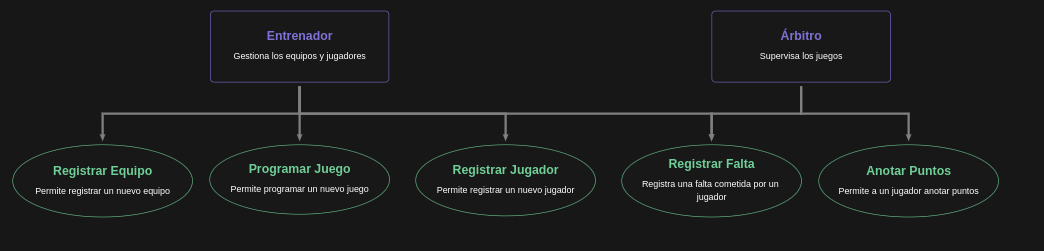

##### 2.1.2 Relaciones identificadas:

-   Un equipo pertenece a una conferencia (uno a muchos).
-   Un jugador pertenece a un equipo (uno a muchos).
-   Un juego se realiza en un estadio y en una temporada (uno a muchos).
-   Un juego involucra a varios equipos (muchos a muchos) a través de **Game_Team**.
-   Un jugador puede cometer varias faltas en varios juegos (muchos a muchos) a través de **Player_Fault**.
-   Un equipo tiene una posición por temporada (uno a muchos).
-   Un jugador puede anotar puntos en varios juegos en distintas temporadas (muchos a muchos) a través de **Player_Point**.

#### 2.2\. Fase de Diseño Lógico (Modelo Lógico de Datos - MLD)

##### 2.2.1 Tablas y atributos:

-   **Conference** (`id`, `name`, `division_name`)
-   **Team** (`id`, `name`, `conference_id`)
-   **Player** (`id`, `team_id`, `name`)
-   **Stadium** (`id`, `name`, `city`)
-   **Fault** (`id`, `name`)
-   **Season** (`id`, `year`, `name`)
-   **Game** (`id`, `date`, `stadium_id`, `season_id`)
-   **Game_Team** (`id`, `game_id`, `team_id`, `winner`, `points`)
-   **Player_Fault** (`id`, `player_id`, `game_id`, `fault_id`)
-   **Team_Position** (`id`, `team_id`, `position`, `season_id`)
-   **Player_Point** (`id`, `player_id`, `game_id`, `three_point`, `two_point`, `free_point`, `season_id`)

##### 2.2.2 Claves primarias y foráneas:

-   Cada tabla tiene una clave primaria única (`id`).
-   Se establecen claves foráneas para representar las relaciones entre las tablas (`conference_id`, `team_id`, `game_id`, `season_id`, `fault_id`, `player_id`).

#### 2.3\. Fase de Diseño Físico (Modelo Físico de Datos - MPD)
--------------------------------------------------
-   **Tipos de datos**: Se utilizan tipos como `INT`, `VARCHAR`, `ENUM`, `DATE` y `FLOAT`.
-   **Restricciones de integridad**: `NOT NULL`, `AUTO_INCREMENT`, claves primarias y foráneas.
-   **Índices**: Para mejorar el rendimiento de las consultas en campos clave (por ejemplo, `game_id`, `team_id`, `player_id`).
-   **Reglas de integridad referencial**: Definidas mediante claves foráneas para asegurar la coherencia de los datos.

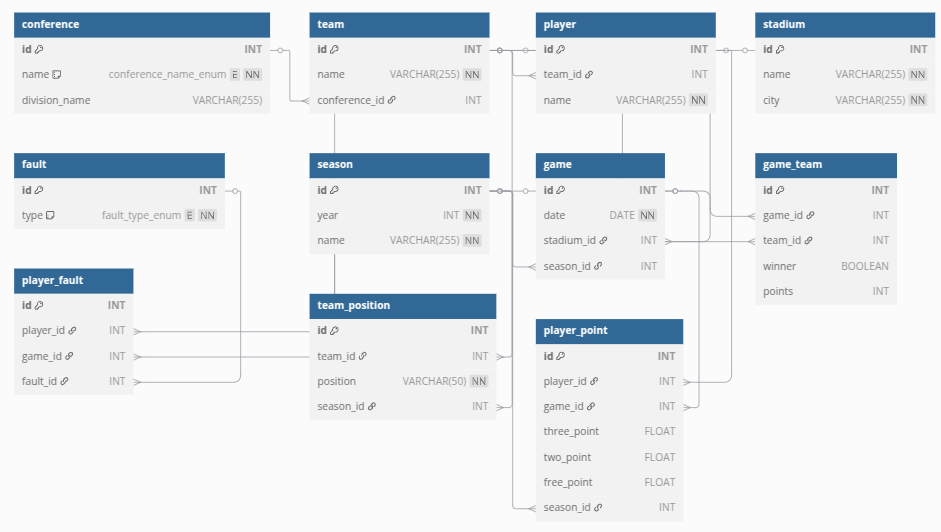

Primero tenemos que intalar mySQL en esta libreta de python.

##**3. Conectar con la base de datos y eliminar tablas existentes**

In [ ]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.0/34.0 MB 27.3 MB/s eta 0:00:00


In [ ]:
import mysql.connector

# Reemplaza los parámetros con los valores de tu entorno.
conexion = mysql.connector.connect(
        user="dav_gal",
        password="dav.73gal_61",
        host="82.165.173.36",
        port="31234"
    )

print("Conexión exitosa a la base de datos.")

cursor = conexion.cursor();

Conexión exitosa a la base de datos.


In [ ]:
# cursor.execute("""
#     CREATE DATABASE IF NOT EXISTS dam_proyecto2T_g2
# """)
cursor.execute("USE damL_proyecto2T_g2")

In [ ]:
# Desactivar la verificación de claves foráneas
cursor.execute("SET foreign_key_checks = 0;")
cursor.execute("""
    DROP TABLE IF  EXISTS
    conference,
    team,
    player,
    stadium,
    fault,
    season,
    game,
    game_team,
    player_fault,
    team_position,
    player_point;
""")
# Desactivar la verificación de claves foráneas
cursor.execute("SET foreign_key_checks = 1;")
# Mostrar las tablas creadas
cursor.execute("SHOW TABLES")
tables = cursor.fetchall()
print(tables)

[]


##**4. Creación de las tablas**

In [ ]:
# Tabla de Conferencias

cursor.execute(
    """
      CREATE TABLE conference (
        id INT PRIMARY KEY AUTO_INCREMENT,
        name ENUM ('east', 'west') NOT NULL,
        division_name VARCHAR(255)
      );
""")

# Tabla de Equipos

cursor.execute(
    """
      CREATE TABLE team (
        id INT PRIMARY KEY AUTO_INCREMENT,
        name VARCHAR(255) NOT NULL,
        conference_id INT,
        FOREIGN KEY (conference_id) REFERENCES conference (id)
      );
""")

# Tabla de Jugadores

cursor.execute(
  """
    CREATE TABLE player (
      id INT PRIMARY KEY AUTO_INCREMENT,
      team_id INT,
      name VARCHAR(255) NOT NULL,
      FOREIGN KEY (team_id) REFERENCES team (id)
    );
""")

# Tabla de Estadios

cursor.execute(
  """
    CREATE TABLE stadium (
      id INT PRIMARY KEY AUTO_INCREMENT,
      name VARCHAR(255) NOT NULL,
      city VARCHAR(255) NOT NULL
    );
""")

# Tabla de Faltas
cursor.execute(
  """
    CREATE TABLE fault (
      id INT PRIMARY KEY AUTO_INCREMENT,
      name ENUM ('technical', 'personal', 'unsportsmanlike') NOT NULL
    );
""")

# Tabla de Temporada

cursor.execute(
"""
  CREATE TABLE season (
    id INT PRIMARY KEY AUTO_INCREMENT,
    year INT NOT NULL,
    name VARCHAR(255) NOT NULL
  );
""")

# Tabla de Partido

cursor.execute(
  """
    CREATE TABLE game (
      id INT PRIMARY KEY AUTO_INCREMENT,
      date DATE NOT NULL,
      stadium_id INT,
      season_id INT,
      FOREIGN KEY (stadium_id) REFERENCES stadium (id),
      FOREIGN KEY (season_id) REFERENCES season (id)
);
""")



# Tabla intermedia entre Partido y Equipo
cursor.execute(
  """
    CREATE TABLE game_team (
      id INT PRIMARY KEY ,
      game_id INT,
      team_id INT,
      winner BOOLEAN,
      points INT,
      FOREIGN KEY (game_id) REFERENCES game (id),
      FOREIGN KEY (team_id) REFERENCES team (id)
    );
""")



#Tabla intermedia de Jugadores y faltas
cursor.execute(
  """
    CREATE TABLE  player_fault (
      id INT PRIMARY KEY AUTO_INCREMENT,
      player_id  INT,
      game_id  INT,
      fault_id  INT,
      FOREIGN KEY (player_id)  REFERENCES  player (id),
      FOREIGN KEY (game_id) REFERENCES game (id),
      FOREIGN KEY (fault_id) REFERENCES fault (id)
    );
""")

# Tabla Posición del equipo

cursor.execute(
  """
    CREATE TABLE team_position (
      id INT PRIMARY KEY AUTO_INCREMENT,
      team_id INT,
      position VARCHAR(50) NOT NULL,
      season_id INT,
      FOREIGN KEY (team_id) REFERENCES team (id),
      FOREIGN KEY (season_id) REFERENCES season (id)
    );
""")

# Tabla intermedia entre Jugadores y puntos

cursor.execute(
  """
    CREATE TABLE player_point (
      id INT PRIMARY KEY AUTO_INCREMENT,
      player_id INT,
      game_id INT,
      three_point FLOAT,
      two_point FLOAT,
      free_point FLOAT,
      season_id INT,
      FOREIGN KEY (player_id) REFERENCES player (id),
      FOREIGN KEY (game_id) REFERENCES game (id),
      FOREIGN KEY (season_id) REFERENCES season (id)
    );
""")

#####4.0.1 Importamos la ruta de GitHub


In [ ]:
!git clone https://github.com/DavidGallardoDigi/proyectoDbNba.git
import sys
sys.path.append("/content/proyectoDbNba")

Cloning into 'proyectoDbNba'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 29 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 32.25 KiB | 485.00 KiB/s, done.
Resolving deltas: 100% (8/8), done.


###4.1 Tabla de conferencias

In [ ]:
#  Insertamos los datos de la tabla Conferencia
from data_conference import data_insert_conference
cursor.execute(data_insert_conference)
conexion.commit()

###4.2 Tabla de Equipos

In [ ]:
#  Insertamos los datos de la tabla Equipos
from data_team import data_insert_team
cursor.execute(data_insert_team)
conexion.commit()

###4.3 Tabla de Jugadores

In [ ]:
#  Insertamos los datos de la tabla Jugadores
from data_player import data_insert_player
cursor.execute(data_insert_player)
conexion.commit()

###4.4 Tabla de Estadios

In [ ]:
#  Insertamos los datos de la tabla Estadios
from data_stadium import data_insert_stadium
cursor.execute(data_insert_stadium)
conexion.commit()

###4.5 Tabla de Falta

In [ ]:
#  Insertamos los datos de la tabla Faltas
from data_fault import data_insert_fault
cursor.execute(data_insert_fault)
conexion.commit()

###4.6 Tabla de Temporada

In [ ]:
#  Insertamos los datos de la tabla Temporada
from data_season import data_insert_season
cursor.execute(data_insert_season)
conexion.commit()

###4.7 Tabla de Partido

In [ ]:
#  Insertamos los datos de la tabla Partido
from data_game import data_insert_game
cursor.execute(data_insert_game)
conexion.commit()

###4.8 Tabla intermedia Partido y Equipo

In [ ]:
#  Insertamos los datos de la tabla Partido_Equipo
from data_game_team import data_insert_game_team
cursor.execute(data_insert_game_team)
conexion.commit()

###4.9 Tabla intermedia Jugador y Falta

In [ ]:
#  Insertamos los datos de la tabla Jugadores_Faltas
from data_player_fault import data_insert_player_fault
cursor.execute(data_insert_player_fault)
conexion.commit()

###4.10 Tabla Posición

In [ ]:
#  Insertamos los datos de la tabla Posición
from data_team_position import data_inser_team_position
cursor.execute(data_inser_team_position)
conexion.commit()

###4.11 Tabla intermedia Jugador Puntos

In [ ]:
#  Insertamos los datos de la tabla Jugadores_Puntos
from data_player_point import data_insert_player_point
cursor.execute(data_insert_player_point)
conexion.commit()